Rod Ciombor <br>
3/14/26<br>
CIS-2532-NET01<br>
Dr. Sheikh Shamsuddin<br>
Week 7 Lab

<b>Functions library contents</b><br>
Here is a list of the contents in <b>week7hw.py</b>
<br><br>

In [ ]:
# Author:       Rod Ciombor
# Date:         03/14/2026
# Instructor:   Dr. Sheikh Shamsuddin
# Class:        CIS-2532-NET01

import numpy as np;
import csv
import statistics as st
import os
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))

def question1():

    list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    arr = np.array(list)
    numbers = arr.reshape(3, 5)
    
    print('Numbers')
    print(numbers)
    print()

    #Question 1a
    print('Row 2')
    print(numbers[2])
    print()

    #Question 1b
    print('Column 4')
    print(numbers[:, 4])
    print()

    #Question 1c
    print('Rows 0 and 1')
    print(numbers[:2])
    print()

    #Question 1d
    print('Columns 2 - 4')
    print(numbers[:, 2:])
    print()

    #Question 1e
    print('Element in row 1 of column 4')
    print(numbers[1, 4])
    print()

    #Question 1f
    print('Elements from rows 1 and 2 that are in columns 0, 2 and 4')
    print(numbers[[1, 2]][:, [0, 2, 4]])
    print()

def question2():
    #Get data from CSV
    data = getDatFromCsv()
    print()

    #Display all data on screen
    print(data)
    print()

    #Determine how many students were in the dataset
    numStudents = len(data[:])
    print(f'There are {numStudents} students')
    print()
    
    #Display number of rows and columns in array
    print('Display numbers of rows and columns')
    print(data.shape)
    print()

    #Display array datatypes
    print('Display data type')
    print(data.dtype)
    print()

    #Display Descriptive Stats
    displayDescriptiveStats(data)
    print()

    #Get Total students by grade category
    displayStudentGradeCategories(data)
    print()

def question2_PieChart():
    #Get data from CSV
    data = getDatFromCsv()

    #Display pie chart
    displayStudentGradeCategories(data, True)
    print()

def getDatFromCsv():
    '''
    Name:
    getDatFromCsv()

    Parameters:
    None

    Returns:
    data --> NumPy array containing the student grade data read from the CSV file

    Descr:
    This function reads the contents of the 'Student_Grades.csv' file located in
    the same directory as the script.

    It builds the full file path using the script directory, then opens the file
    and reads all rows using the csv module.

    The first row of the file contains column headers, which are removed because
    they are not part of the numeric dataset.

    The remaining rows are converted into a NumPy array of float64 values and
    returned for further analysis.
    '''
    #Build filepath
    filePath = os.path.join(SCRIPT_DIR, 'Student_Grades.csv')

    #Get file contents
    with open(filePath, 'r') as f:
        data = list(csv.reader(f))
    
    #Convert to array and return
    #Skip first row - column headers
    return np.array(data[1:], dtype=np.float64)

def displayDescriptiveStats(data):
    '''
    Name:
    displayDescriptiveStats()

    Parameters:
    data --> NumPy array containing the student grade dataset

    Returns:
    None

    Descr:
    This function calculates and displays descriptive statistics for the
    overall student scores contained in the dataset.

    The function extracts the final column of the array, which represents
    each student's overall percentage grade.

    It then calculates and prints several descriptive statistics including
    the minimum score, maximum score, mean, median, mode, and standard
    deviation.

    Finally, it calculates the 25th and 75th percentiles of the grades and
    prints them to provide additional insight into the distribution of
    scores.
    '''

    #Overall % is last column
    grades = data[:, -1]

    print('Descriptive Statistics...')
    #Min score
    print(f'\tMin overall score: ', grades.min())
    #Max Score
    print(f'\tMax overall score: ', grades.max())
    #Mean value
    print(f'\tMean: ', grades.mean())
    #Median
    print(f'\tMedian: ', st.median(grades))
    #Mode
    print(f'\tMode: ', st.mode(grades))
    #Standard Deviation
    print(f'\tStd. Dev.: ', grades.std())
    #25% and 75% percentile
    percentiles = [
        float(np.percentile(grades, 25)),
        float(np.percentile(grades, 75))
    ]
    print(f'\tPercentile (25%, 75%): ', percentiles)

def groupStudentsByGrade(data):
    '''
    Name:
    groupStudentsByGrade()

    Parameters:
    data --> NumPy array containing the student grade dataset

    Returns:
    List containing the number of students in each
    grade category in the following order: A, B, C, D, F

    Descr:
    This function groups students into grade categories based on their
    overall percentage scores.

    The function extracts the last column of the dataset, which represents
    each student's overall percentage grade.

    It then creates logical conditions to determine whether each grade
    falls within the ranges for A (90 and above), B (80 to 89.99),
    C (70 to 79.99), D (60 to 69.99), or F (below 60).

    Using these conditions, the function counts how many students fall
    into each category and returns the totals as a list.
    '''
    #Overall % is last column
    grades = data[:, -1]

    catA = grades >= 90.0
    catB = (grades < 90.0) & (grades >= 80.0)
    catC = (grades < 80.0) & (grades >= 70.0)
    catD = (grades < 70.0) & (grades >= 60.0)
    catF = grades < 60.0

    return [
        grades[catA].shape[0],
        grades[catB].shape[0],
        grades[catC].shape[0],
        grades[catD].shape[0],
        grades[catF].shape[0]
    ]

def displayStudentGradeCategories(data, showChart=False):
    '''
    Name:
    displayStudentGradeCategories()

    Parameters:
    data --> NumPy array containing the student grade dataset
    showChart --> Boolean value indicating whether to display a pie chart
                (True) or print the grade category counts (False)

    Returns:
    None

    Descr:
    This function displays the number of students in each grade category
    (A, B, C, D, F) based on their overall percentage scores.

    The function first calls groupStudentsByGrade() to determine how many
    students fall into each grade category.

    If showChart is set to True, the function calculates the percentage
    of students in each category relative to the total number of students.
    It then builds and displays a pie chart showing the distribution of
    student performance across the grade categories.

    If showChart is set to False, the function prints the number of
    students in each grade category to the console.
    '''
    letters = ['A', 'B', 'C', 'D', 'F']
    i = 0

    #Get category counts
    categories = groupStudentsByGrade(data)
    
    if showChart:
        percentages = []
        labels = []
        totalStudents = np.sum(categories)
        for cat in categories:
            #Calculate percentages
            percent = cat / totalStudents
            percentages.append(percent)
            #Create labels
            labels.append(letters[i] + ' std')
            i = i + 1
        
        #Build pie chart
        plt.pie(percentages, labels=labels)
        plt.title('Student Performance Pie Chart')
        plt.show()
    else:
        print('Number of students achieved in each grade category:')
        for cat in categories:
            print(f'{cat} {letters[i]}')
            i = i + 1


<b>Question 1 Output</b><br>
Here is the output for question 1
<br><br>

In [1]:
import week7hw as lib
lib.question1()


Numbers
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]]

Row 2
[11 12 13 14 15]

Column 4
[ 5 10 15]

Rows 0 and 1
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]

Columns 2 - 4
[[ 3  4  5]
 [ 8  9 10]
 [13 14 15]]

Element in row 1 of column 4
10

Elements from rows 1 and 2 that are in columns 0, 2 and 4
[[ 6  8 10]
 [11 13 15]]



<b>Question 2 Output</b><br>
Here is the output for question 2 (not counting the Pie Chart)
<br><br>

In [2]:
import week7hw as lib
lib.question2()



[[  15.        50.        50.      ...  207.      1442.        94.1868 ]
 [  15.        50.        50.      ...  197.      1322.        86.34879]
 [  15.        50.        50.      ...  210.      1510.        98.62834]
 ...
 [  15.        50.        50.      ...  200.      1374.        89.74526]
 [  15.        50.        50.      ...  195.      1287.        84.0627 ]
 [  15.        50.        50.      ...  210.      1490.        97.32201]]

There are 33 students

Display numbers of rows and columns
(33, 32)

Display data type
float64

Descriptive Statistics...
	Min overall score:  29.65382
	Max overall score:  99.86936
	Mean:  87.66996787878789
	Median:  92.88047
	Mode:  94.1868
	Std. Dev.:  15.553686425410683
	Percentile (25%, 75%):  [87.1979, 96.73416]

Number of students achieved in each grade category:
21 A
8 B
1 C
1 D
2 F



<b>Question 2 Pie Chart Output</b><br>
Here is the output for question 2 Pie Chart
<br><br>

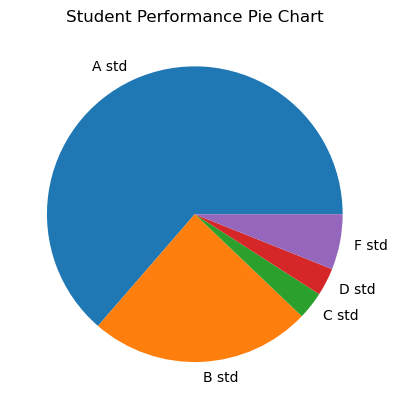

In [4]:
import week7hw as lib
lib.question2_PieChart()
